# Puzzle

### This Week’s Fiddler
My friend has three cups, labeled “A,” “B,” and “C” in a row. She randomly picks two different cups and swaps their positions. Then she does this again and again, picking a random pair each time, until all three cups are back in their original order. For example, here is one such sequence of swaps:

A, B, C (original)

C, B, A (first and third were swapped)

B, C, A (first and second were swapped)

B, A, C (second and third were swapped)

A, B, C (first and second were swapped)

In this example, the cups returned to their original order after four swaps.

On average, how many swaps would you expect until the cups return to their original order?

### This Week’s Extra Credit
In total, there are six possible orders of the cups. Without any swaps, one of those orders (A, B, C) has already been achieved.

On average, how many swaps would you expect until the remaining five orders (and thus, all six) are also achieved?

# Solution Setup

We can draw this situation as a graph.

```mermaid
graph TB
  subgraph Even
    E1(E1:ABC):::Blue
    E2(E2:BCA):::Blue
    E3(E3:CAB):::Blue
  end
  subgraph Odd
    O1(O1:BAC):::Purple
    O2(O2:ACB):::Purple
    O3(O3:CBA):::Purple
  end
  E1 --1/3--> O1 --1/3--> E1
  E1 --1/3--> O2 --1/3--> E1
  E1 --1/3--> O3 --1/3--> E1
  E2 --1/3--> O1 --1/3--> E2
  E2 --1/3--> O2 --1/3--> E2
  E2 --1/3--> O3 --1/3--> E2
  E3 --1/3--> O1 --1/3--> E3
  E3 --1/3--> O2 --1/3--> E3
  E3 --1/3--> O3 --1/3--> E3

  classDef Blue fill:#8FFFFF,stroke:#276d9d,color:#000;
  classDef Purple fill:#A05EBB,stroke:#6c49a8,color:#fff;
```

Mermaid is not rendering, so here's a screenshot.

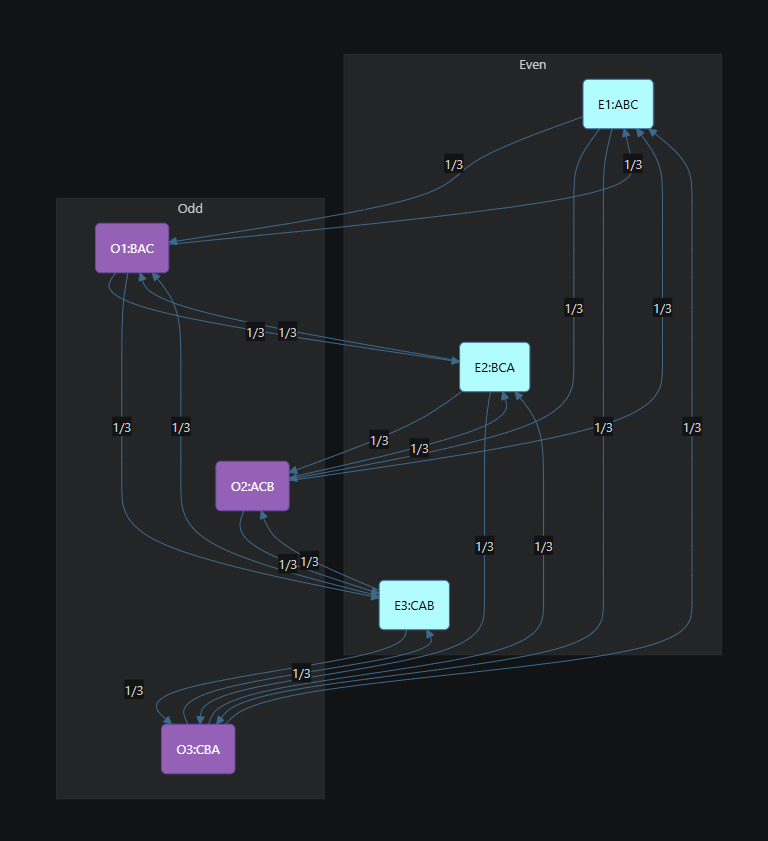

It's not the best way to render this graph, but it'll do.

This graph has a bipartite structure. I.e. edges go from the even group to the odd group and vice versa, but there are no within group edges (i.e. edges from even-to-even or odd-to-odd)

So you can only be in the even nodes (E1,E2,E3) after a even number of swaps, and in the odd nodes(O1,O2,O3) after an odd number of swaps 

# Fiddler solution.

For the fiddler case, the graph can be simplified further by merging some states to:

```mermaid
graph TB
  E1(E1:ABC):::Blue
  E23(E23:BCA,CAB):::Blue
  O123(O123:BAC,ACB,CBA):::Purple
  
  E1 --1--> O123 --1/3--> E1
  E23 --1--> O123 --2/3--> E23
  
  classDef Blue fill:#8FFFFF,stroke:#276d9d,color:#000;
  classDef Purple fill:#A05EBB,stroke:#6c49a8,color:#fff;
```

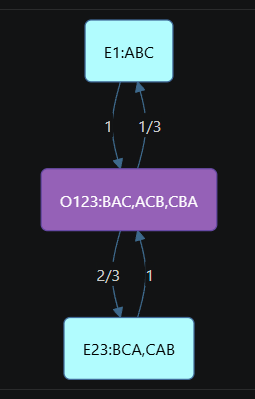


So, we can see a few things:

* Since E1:ABC is a even node, we can reach it only after an even number of swaps, say 2k swaps with k > 1.
* There is no choice in the next state after the E* states - we always transition to the O123 state.
* The only way to reach E1:ABC after exactly 2k swaps is that O123 transitions to E23 k-1 times and to E1 1 time.
    * The probability of this is $(2/3)^{k-1}(1/3)$

So, the expected number of swaps can calculated as the sum:

$ S = \sum_{k=1}^{\infty} (2/3)^{k-1}(1/3)(2k) $

$ S = \sum_{k=1}^{\infty} (2/3)^{k-1}(2/3)(k) $

$ S = \sum_{k=1}^{\infty} (2/3)^{k}(k) $

This is an arithmetico-geometric  series, and can be evaluated in the standard way.

$ S = \sum_{j=1}^{\infty} \sum_{k=j}^{\infty} (2/3)^{k} $

$ S = \sum_{j=1}^{\infty} 3 \times (2/3)^{j} $

$ S = 3 \times \sum_{j=1}^{\infty} (2/3)^{j} $

$ S = 3 \times 3 \times (2/3)^{1} $

$ S = 6 $

So, the fiddler answer is that we can expect to take 6 swaps on average to return to the starting position.

# Extra Credit Solution

Since we start with one configuration and need to visit 5 others, we need at least 5 swaps. But beyond that, we could take any number of swaps. 

Let $P(x)$ be the probability of finishing visiting all the configurations in exactly $x$ swaps.

Let's count the number of ways we could finish visiting all the configurations in a particular number of swaps.

### Even Swaps Case

Let's say we finish visiting all the configurations in an even number of swaps = 2k.

Because the number of states is 1 + the number of swaps, we'll have been in an even (E*) state k+1 times and an odd (O*) state k times.

We'll always start from E1, so there is no choice there.

And if the final state is E3 (or E2), it will be the first time we are reaching E3 (or E2). Because if not, we would have finished visiting all the states earlier.

So, the sequence of states on the even side will be something like: 
* E1
* E1 or E2 (or E3) k-1 times but not all E1.
* E3 (or E2)

So, we have 2 options about which state we end in, and $2^{k-1} - 1$ options about the states in between the first and last state. i.e. 

even state arrangements = $2^k - 2$

On the odd side, we can visit any state in any order, but we have to visit all states, so we must exclude configurations that are made up of just 2 states or 1 state. Similar to inclusion-exclusion

odd state arrangements = $3^k - 3 * 2^k + 3 * 1^k$

odd state arrangements = $3^k - 3 * 2^k + 3 $

Putting it all together

$P(2k) = (2^k-2)(3^k-3*2^k+3)/(3^{2k})$


### Odd Swaps Case

Let's say we finish visiting all the configurations in an even number of swaps = 2k+1.

Because the number of states is 1 + the number of swaps, we'll have been in an even (E*) state k+1 times and an odd (O*) state k+1 times.

We'll always start from E1, so there is no choice there.

And if the final state is E3 (or E2), it will be the first time we are reaching E3 (or E2). Because if not, we would have finished visiting all the states earlier.

So, the sequence of states on the even side will be something like: 
* E1
* E1 or E2 or E3 in any order, but we have to definitely visit E2 and E3 (E1 is already covered)
    * This means excluding combinations that consist of only E1+E2 or only E1+E3, but not E2+E3 since that is okay.

Following similar steps, we get:

even state arrangements = $3^k - 2 * 2^k + 1 $

On the odd side, we have *3* options about which state we end in, and $2^{k} - 2$ options about the states in before last state.

odd state arrangements = $3(2^k - 2)$

Putting it all together

$P(2k+1) = 3(2^k-2)(3^k-2*2^k+1)/(3^{2k+1})$

$P(2k+1) = (2^k-2)(3^k-2*2^k+1)/(3^{2k})$

### Expected value

The expected cover time C is:

$ C  = \sum_{k=3}^{\infty} (2k)P(2k) + \sum_{k=2}^{\infty} (2k+1)P(2k+1) $

While we could try to evaluate this sum by breaking it up into a number (12?) of arithmetico-geometric series, I am going to first try to evaluate it numerically.

In [27]:
from math import pow

def P(x, exact_powers=False):
    if x < 5:
        return 0
    
    k, odd = divmod(x, 2)
    kth_power_of_2 = 2**k if exact_powers else pow(2, k)
    kth_power_of_3 = 3**k if exact_powers else pow(3, k)
    xth_power_of_3 = 3**x if exact_powers else pow(3, x)
            
    if odd == 0:
        even_arrangements = kth_power_of_2 - 2
        odd_arrangements = kth_power_of_3 - 3* kth_power_of_2 + 3
        p = even_arrangements * odd_arrangements / xth_power_of_3
        return p
    else:
        odd_arrangements = 3*(kth_power_of_2 - 2)
        even_arrangements = kth_power_of_3 - 2* kth_power_of_2 + 1
        p = even_arrangements * odd_arrangements / xth_power_of_3
        return p

def C(max_term, exact_powers=False):
    exp_val_sum = 0
    for x in range(5, max_term + 1):
        exp_val_sum += P(x, exact_powers) * x
    return exp_val_sum

In [28]:
for max_term in range(100, 251, 20):
    for exact_powers in [False, True]:
        print(f"Expected value based on terms from 5 to {max_term:3} swaps: {C(max_term, exact_powers)}")

Expected value based on terms from 5 to 100 swaps: 12.214284887776566
Expected value based on terms from 5 to 100 swaps: 12.214284887776566
Expected value based on terms from 5 to 120 swaps: 12.214285697233052
Expected value based on terms from 5 to 120 swaps: 12.214285697233052
Expected value based on terms from 5 to 140 swaps: 12.214285713942823
Expected value based on terms from 5 to 140 swaps: 12.214285713942823
Expected value based on terms from 5 to 160 swaps: 12.214285714278944
Expected value based on terms from 5 to 160 swaps: 12.214285714278944
Expected value based on terms from 5 to 180 swaps: 12.214285714285577
Expected value based on terms from 5 to 180 swaps: 12.214285714285577
Expected value based on terms from 5 to 200 swaps: 12.214285714285705
Expected value based on terms from 5 to 200 swaps: 12.214285714285705
Expected value based on terms from 5 to 220 swaps: 12.214285714285705
Expected value based on terms from 5 to 220 swaps: 12.214285714285705
Expected value based

Assuming I did not make a mistake, we can see that the sum converges to 12.214285714285705 with no visible digits changing by 200 terms. Of course, there must be some error.

Since this has the repeating 142857 structure, we can reasonably guess that this is something divided by 7, and infer that the exact value is 171/14 = 12.2142857142857142857142857142857...

I think the best next step is to do some random simulation of the original situation to make sure we are on the right track, since it is easy to mix up some terms.

In [29]:
import random

# Simulate both Fiddler and extra credit together for efficiency.
def one_seq_of_swaps():
    next_states = {}
    next_states['E1'] = ['O1', 'O2', 'O3']
    next_states['E2'] = ['O1', 'O2', 'O3']
    next_states['E3'] = ['O1', 'O2', 'O3']
    next_states['O1'] = ['E1', 'E2', 'E3']
    next_states['O2'] = ['E1', 'E2', 'E3']
    next_states['O3'] = ['E1', 'E2', 'E3']

    current_state = 'E1'
    states_visited = set([current_state])
    num_swaps = 0
    E1_revisit_swaps = None
    All_visit_swaps = None
    while True:
        current_state = random.choice(next_states[current_state])
        states_visited.add(current_state)
        num_swaps += 1
        if  E1_revisit_swaps is None and current_state == 'E1':
            E1_revisit_swaps = num_swaps
        if All_visit_swaps is None and len(states_visited) == 6:
            All_visit_swaps = num_swaps
        if All_visit_swaps is not None and E1_revisit_swaps is not None:
            return E1_revisit_swaps, All_visit_swaps

In [30]:
def simulate_many(num_trials):
    E1_revisit_sum = 0
    All_visit_sum = 0
    for _ in range(num_trials):
        E1_revisit_swaps, All_visit_swaps = one_seq_of_swaps()
        E1_revisit_sum += E1_revisit_swaps
        All_visit_sum += All_visit_swaps
    Fiddler_estimate = E1_revisit_sum / num_trials
    EC_estimate = All_visit_sum / num_trials
    return Fiddler_estimate, EC_estimate

In [31]:
for trials in [1000, 10000, 100000, 1000000, 100000000]:
    Fiddler_estimate, EC_estimate = simulate_many(trials)
    print (f"Fiddler: {Fiddler_estimate}, Extra Credit: {EC_estimate}")

Fiddler: 5.998, Extra Credit: 12.192
Fiddler: 5.9328, Extra Credit: 12.1892
Fiddler: 5.99152, Extra Credit: 12.22705
Fiddler: 5.99577, Extra Credit: 12.21082
Fiddler: 5.9997955, Extra Credit: 12.21490249


# Conclusion

The random sim seems consistent with the prior calculation, and I don't have the mojo to reduce that large number of summations to an exact value, esp since we can guess at the answer.

**Fiddler Answer: 6 swaps** is the expected number of swaps to return to the start state.

**Extra Credit Answer: 171/14 swaps** is the expected number of swaps to achieve all possible configurations.